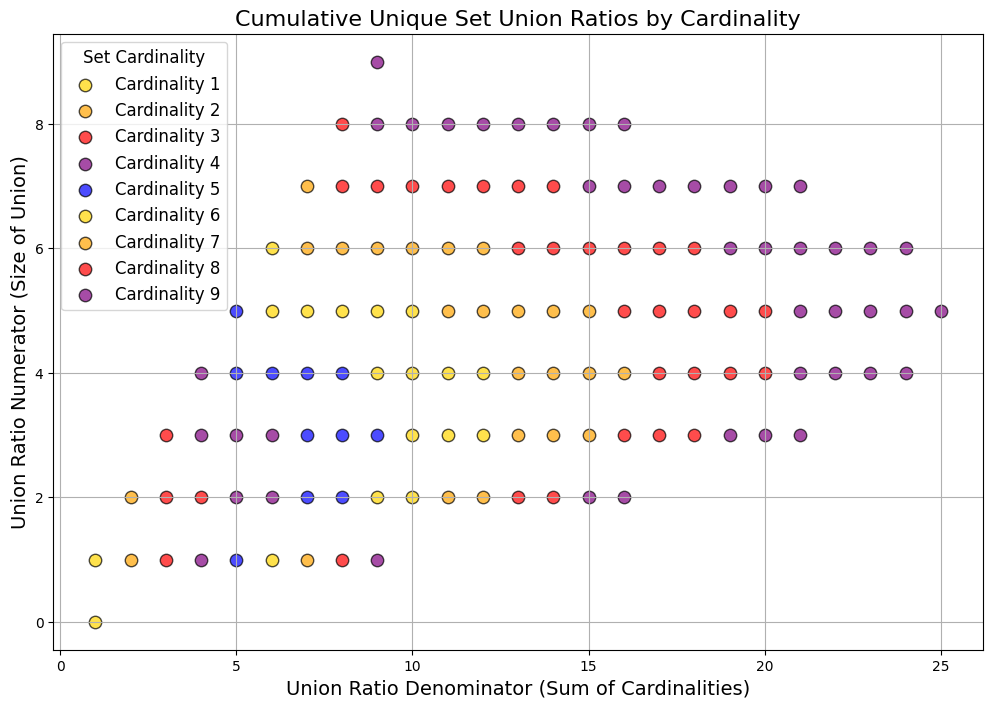

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

def decode_binary_string(binary_str):
    decoded_sets = []
    positions_of_ones = [i for i, bit in enumerate(binary_str) if bit == '1']
    next_set_index = 0

    for position in positions_of_ones:
        n = next_set_index
        cardinality = position - n + 1
        if cardinality <= 0:
            raise ValueError(f"Invalid cardinality ({cardinality}) at position {position}.")
        current_set = set(range(1, cardinality + 1))
        decoded_sets.append(current_set)
        next_set_index += 1

    return decoded_sets

def set_union_ratio(collection_of_sets):
    union_of_sets = set().union(*collection_of_sets)
    sum_of_cardinalities = sum(len(s) for s in collection_of_sets)
    if sum_of_cardinalities == 0:
        return (0, 1)
    return (len(union_of_sets), sum_of_cardinalities)

def generate_powerset_binary_strings(cardinality):
    return [''.join(bits) for bits in product('01', repeat=cardinality)]

def generate_dataframe(cardinality_range):
    results = []
    for set_cardinality in cardinality_range:
        binary_strings = generate_powerset_binary_strings(set_cardinality)
        for binary in binary_strings:
            try:
                decoded = decode_binary_string(binary)
                numerator, denominator = set_union_ratio(decoded)
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': decoded,
                    'Union Ratio Numerator': numerator,
                    'Union Ratio Denominator': denominator
                })
            except ValueError as e:
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': str(e),
                    'Union Ratio Numerator': None,
                    'Union Ratio Denominator': None
                })

    df = pd.DataFrame(results)
    return df

def plot_cumulative_ratios(df, cardinality_range):
    plt.figure(figsize=(12, 8))
    seen_points = set()
    colors = ['gold', 'orange', 'red', 'purple', 'blue']

    for idx, cardinality in enumerate(cardinality_range):
        subset_df = df[
            (df['Set Cardinality'] == cardinality) &
            (df['Union Ratio Numerator'].notnull())
        ]

        current_points = set(zip(subset_df['Union Ratio Denominator'], subset_df['Union Ratio Numerator']))
        new_points = current_points - seen_points
        seen_points.update(new_points)

        if new_points:
            x, y = zip(*new_points)
            plt.scatter(
                x, y,
                s=80,
                alpha=0.7,
                edgecolors='k',
                color=colors[idx % len(colors)],
                label=f'Cardinality {cardinality}'
            )

    plt.title('Cumulative Unique Set Union Ratios by Cardinality', fontsize=16)
    plt.xlabel('Union Ratio Denominator (Sum of Cardinalities)', fontsize=14)
    plt.ylabel('Union Ratio Numerator (Size of Union)', fontsize=14)
    plt.legend(title='Set Cardinality', fontsize=12, title_fontsize=12)
    plt.grid(True)
    plt.show()

def main():
    cardinality_range = range(1, 10)
    df = generate_dataframe(cardinality_range)
    plot_cumulative_ratios(df, cardinality_range)

if __name__ == "__main__":
    main()


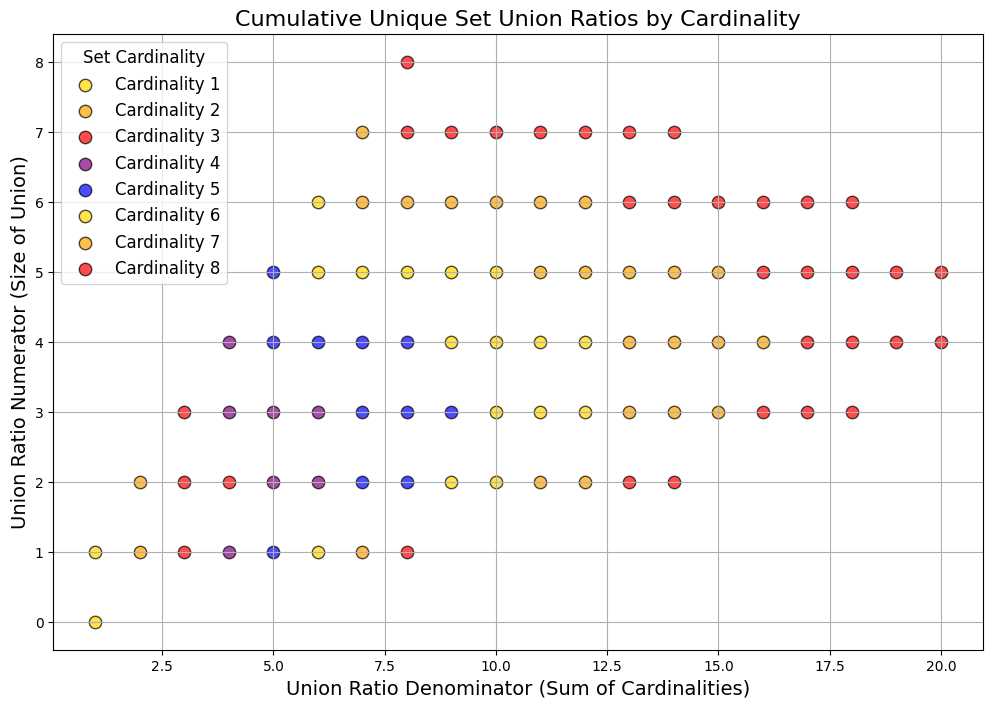

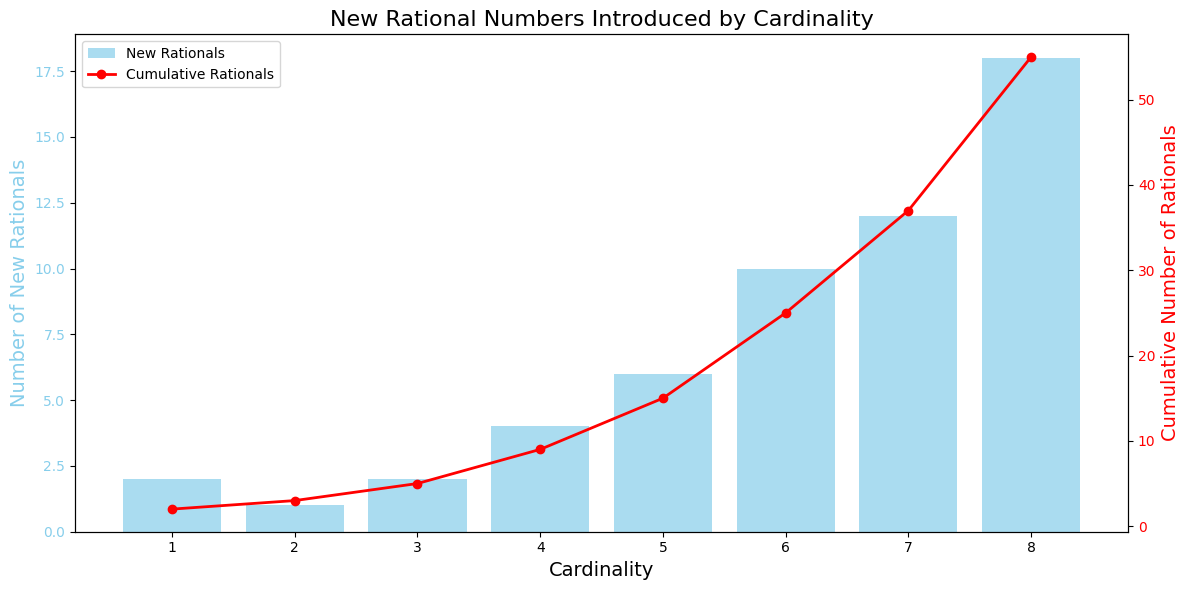

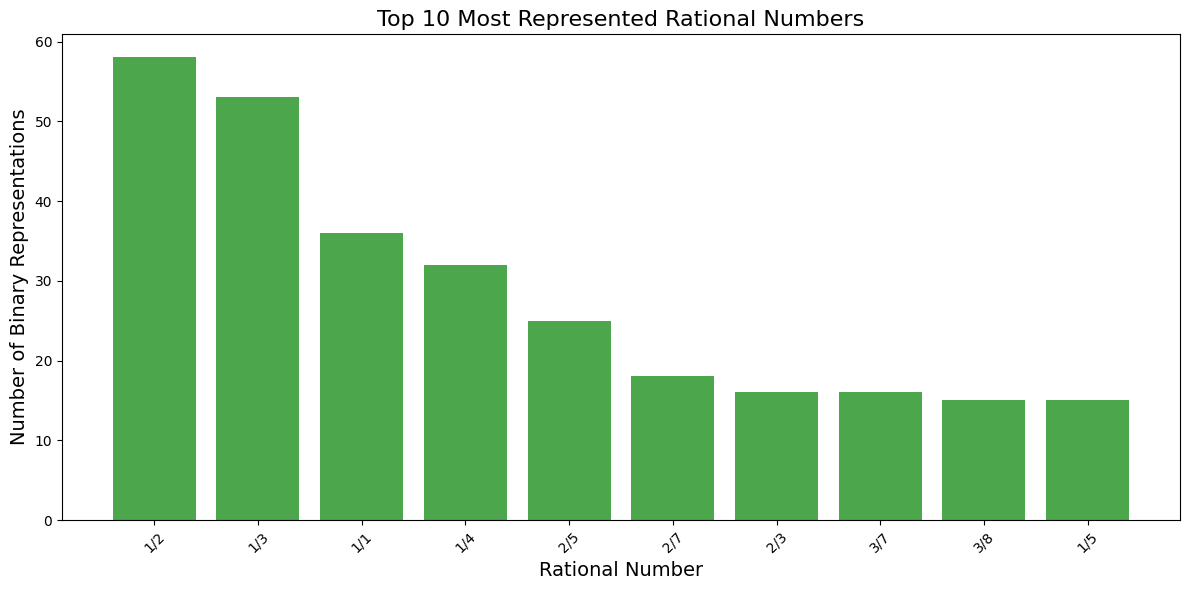


Rational: 1/2
Total representations: 58
Sample representations (up to 5):
  1. Binary: 11 (cardinality: 2)
     Decoded sets: [{1}, {1}]
  2. Binary: 011 (cardinality: 3)
     Decoded sets: [{1, 2}, {1, 2}]
  3. Binary: 110 (cardinality: 3)
     Decoded sets: [{1}, {1}]
  4. Binary: 0011 (cardinality: 4)
     Decoded sets: [{1, 2, 3}, {1, 2, 3}]
  5. Binary: 0110 (cardinality: 4)
     Decoded sets: [{1, 2}, {1, 2}]

Rational: 2/3
Total representations: 16
Sample representations (up to 5):
  1. Binary: 101 (cardinality: 3)
     Decoded sets: [{1}, {1, 2}]
  2. Binary: 1010 (cardinality: 4)
     Decoded sets: [{1}, {1, 2}]
  3. Binary: 01001 (cardinality: 5)
     Decoded sets: [{1, 2}, {1, 2, 3, 4}]
  4. Binary: 10100 (cardinality: 5)
     Decoded sets: [{1}, {1, 2}]
  5. Binary: 010010 (cardinality: 6)
     Decoded sets: [{1, 2}, {1, 2, 3, 4}]

Rational: 3/4
Total representations: 8
Sample representations (up to 5):
  1. Binary: 1001 (cardinality: 4)
     Decoded sets: [{1}, {1, 2, 3}]

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction
import numpy as np

def decode_binary_string(binary_str):
    decoded_sets = []
    positions_of_ones = [i for i, bit in enumerate(binary_str) if bit == '1']
    next_set_index = 0

    for position in positions_of_ones:
        n = next_set_index
        cardinality = position - n + 1
        if cardinality <= 0:
            raise ValueError(f"Invalid cardinality ({cardinality}) at position {position}.")
        current_set = set(range(1, cardinality + 1))
        decoded_sets.append(current_set)
        next_set_index += 1

    return decoded_sets

def set_union_ratio(collection_of_sets):
    if not collection_of_sets:
        return (0, 1)  # Return 0/1 for empty collections
    
    union_of_sets = set().union(*collection_of_sets)
    sum_of_cardinalities = sum(len(s) for s in collection_of_sets)
    
    if sum_of_cardinalities == 0:
        return (0, 1)
    return (len(union_of_sets), sum_of_cardinalities)

def generate_powerset_binary_strings(cardinality):
    return [''.join(bits) for bits in product('01', repeat=cardinality)]

def generate_dataframe(cardinality_range):
    results = []
    for set_cardinality in cardinality_range:
        binary_strings = generate_powerset_binary_strings(set_cardinality)
        for binary in binary_strings:
            try:
                decoded = decode_binary_string(binary)
                numerator, denominator = set_union_ratio(decoded)
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': decoded,
                    'Union Ratio Numerator': numerator,
                    'Union Ratio Denominator': denominator
                })
            except ValueError as e:
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': str(e),
                    'Union Ratio Numerator': None,
                    'Union Ratio Denominator': None
                })

    df = pd.DataFrame(results)
    return df

def build_rational_dictionary(max_cardinality):
    # Dictionary to store rational numbers and their binary representations
    rational_dict = {}
    
    for cardinality in range(1, max_cardinality + 1):
        # Generate all binary strings of length 'cardinality'
        binary_strings = generate_powerset_binary_strings(cardinality)
        
        for binary in binary_strings:
            try:
                # Decode the binary string into sets
                decoded_sets = decode_binary_string(binary)
                
                # Calculate the ratio
                numerator, denominator = set_union_ratio(decoded_sets)
                
                # Convert to simplified fraction
                if denominator > 0:
                    ratio = Fraction(numerator, denominator)
                    
                    # Add to dictionary
                    if ratio not in rational_dict:
                        rational_dict[ratio] = []
                    
                    rational_dict[ratio].append({
                        "binary": binary, 
                        "cardinality": cardinality,
                        "decoded_sets": decoded_sets
                    })
                    
            except ValueError:
                # Skip invalid decodings
                continue
                
    return rational_dict

def analyze_rational_dictionary(rational_dict):
    # Count how many representations each rational has
    representation_counts = {ratio: len(representations) for ratio, representations in rational_dict.items()}
    
    # Find rationals with the most representations
    most_represented = sorted(representation_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    
    # Analyze which cardinalities introduce new rationals
    rationals_by_cardinality = {}
    for ratio, representations in rational_dict.items():
        min_cardinality = min(rep["cardinality"] for rep in representations)
        if min_cardinality not in rationals_by_cardinality:
            rationals_by_cardinality[min_cardinality] = []
        rationals_by_cardinality[min_cardinality].append(ratio)
    
    # Count new rationals introduced at each cardinality
    new_rationals_count = {card: len(ratios) for card, ratios in rationals_by_cardinality.items()}
    
    return {
        "most_represented_rationals": most_represented,
        "new_rationals_by_cardinality": new_rationals_count,
        "rationals_by_cardinality": rationals_by_cardinality
    }

def plot_cumulative_ratios(df, cardinality_range):
    plt.figure(figsize=(12, 8))
    seen_points = set()
    colors = ['gold', 'orange', 'red', 'purple', 'blue']

    for idx, cardinality in enumerate(cardinality_range):
        subset_df = df[
            (df['Set Cardinality'] == cardinality) &
            (df['Union Ratio Numerator'].notnull())
        ]

        current_points = set(zip(subset_df['Union Ratio Denominator'], subset_df['Union Ratio Numerator']))
        new_points = current_points - seen_points
        seen_points.update(new_points)

        if new_points:
            x, y = zip(*new_points)
            plt.scatter(
                x, y,
                s=80,
                alpha=0.7,
                edgecolors='k',
                color=colors[idx % len(colors)],
                label=f'Cardinality {cardinality}'
            )

    plt.title('Cumulative Unique Set Union Ratios by Cardinality', fontsize=16)
    plt.xlabel('Union Ratio Denominator (Sum of Cardinalities)', fontsize=14)
    plt.ylabel('Union Ratio Numerator (Size of Union)', fontsize=14)
    plt.legend(title='Set Cardinality', fontsize=12, title_fontsize=12)
    plt.grid(True)
    plt.show()

def plot_new_rationals_by_cardinality(analysis_results):
    cardinalities = list(analysis_results["new_rationals_by_cardinality"].keys())
    new_rationals = list(analysis_results["new_rationals_by_cardinality"].values())
    
    # Calculate cumulative rationals
    cumulative_rationals = np.cumsum(new_rationals)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot new rationals per cardinality
    ax1.bar(cardinalities, new_rationals, color='skyblue', alpha=0.7, label='New Rationals')
    ax1.set_xlabel('Cardinality', fontsize=14)
    ax1.set_ylabel('Number of New Rationals', fontsize=14, color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')
    
    # Second y-axis for cumulative count
    ax2 = ax1.twinx()
    ax2.plot(cardinalities, cumulative_rationals, color='red', linewidth=2, marker='o', label='Cumulative Rationals')
    ax2.set_ylabel('Cumulative Number of Rationals', fontsize=14, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Title and legend
    plt.title('New Rational Numbers Introduced by Cardinality', fontsize=16)
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

def display_most_represented_rationals(analysis_results):
    most_represented = analysis_results["most_represented_rationals"]
    
    plt.figure(figsize=(12, 6))
    ratios = [f"{ratio.numerator}/{ratio.denominator}" for ratio, count in most_represented]
    counts = [count for _, count in most_represented]
    
    plt.bar(ratios, counts, color='green', alpha=0.7)
    plt.xlabel('Rational Number', fontsize=14)
    plt.ylabel('Number of Binary Representations', fontsize=14)
    plt.title('Top 10 Most Represented Rational Numbers', fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def display_rational_representation_examples(rational_dict, selected_rationals):
    """
    Display examples of binary representations for selected rationals.
    
    Args:
        rational_dict: Dictionary mapping rationals to their representations
        selected_rationals: List of Fraction objects to display
    """
    for rational in selected_rationals:
        if rational in rational_dict:
            print(f"\nRational: {rational.numerator}/{rational.denominator}")
            print(f"Total representations: {len(rational_dict[rational])}")
            print("Sample representations (up to 5):")
            
            # Display up to 5 examples sorted by cardinality
            examples = sorted(rational_dict[rational], key=lambda x: x["cardinality"])[:5]
            for i, example in enumerate(examples, 1):
                print(f"  {i}. Binary: {example['binary']} (cardinality: {example['cardinality']})")
                print(f"     Decoded sets: {example['decoded_sets']}")
        else:
            print(f"\nRational {rational.numerator}/{rational.denominator} not found in dictionary.")

def main():
    # Set the maximum cardinality to explore
    max_cardinality = 8
    cardinality_range = range(1, max_cardinality + 1)
    
    # Generate the dataframe (original approach)
    df = generate_dataframe(cardinality_range)
    
    # Build the rational dictionary (new approach)
    rational_dict = build_rational_dictionary(max_cardinality)
    
    # Analyze the dictionary
    analysis_results = analyze_rational_dictionary(rational_dict)
    
    # Generate various visualizations
    plot_cumulative_ratios(df, cardinality_range)
    plot_new_rationals_by_cardinality(analysis_results)
    display_most_represented_rationals(analysis_results)
    
    # Display examples for specific rationals of interest
    selected_rationals = [Fraction(1, 2), Fraction(2, 3), Fraction(3, 4)]
    display_rational_representation_examples(rational_dict, selected_rationals)
    
    # Print overall statistics
    total_rationals = len(rational_dict)
    print(f"\nTotal unique rational numbers found: {total_rationals}")
    
    # Optionally, you can save the dictionary to a file for further analysis
    # import json
    # with open('rational_dict_serializable.json', 'w') as f:
    #     # Convert to a serializable format first
    #     serializable_dict = {f"{k.numerator}/{k.denominator}": 
    #                          [{**v, "decoded_sets": str(v["decoded_sets"])} for v in vs] 
    #                          for k, vs in rational_dict.items()}
    #     json.dump(serializable_dict, f)

if __name__ == "__main__":
    main()

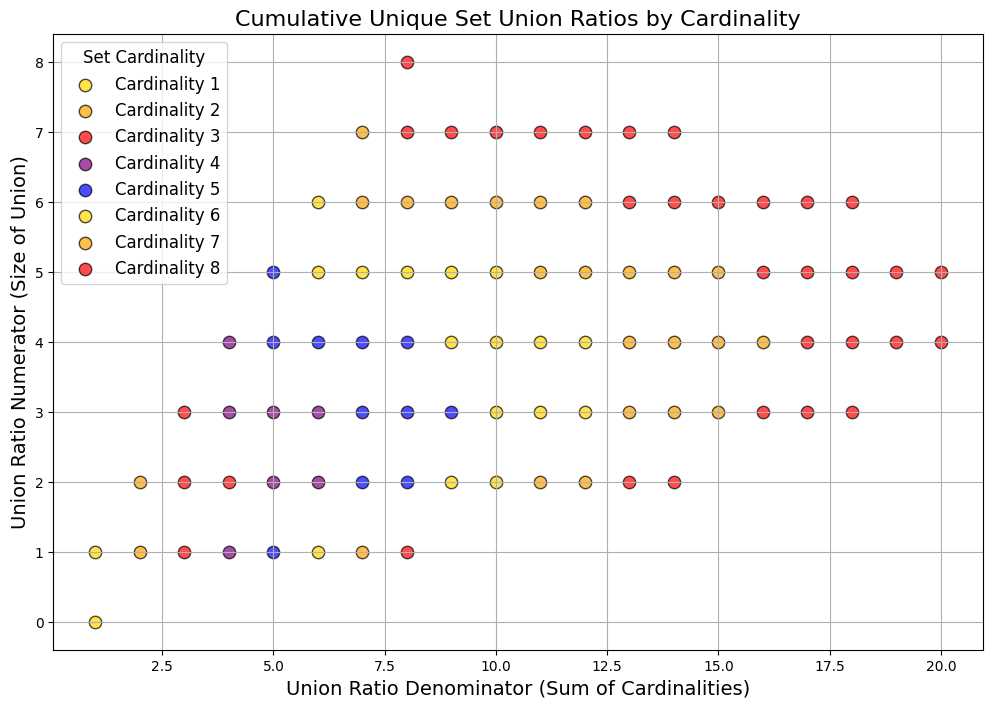

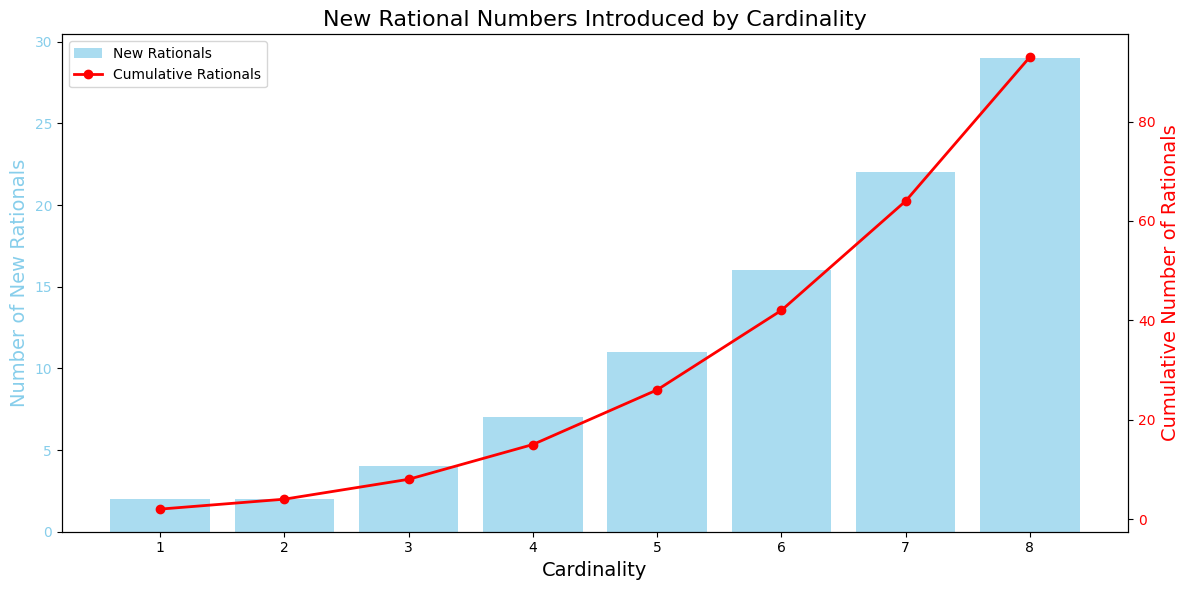

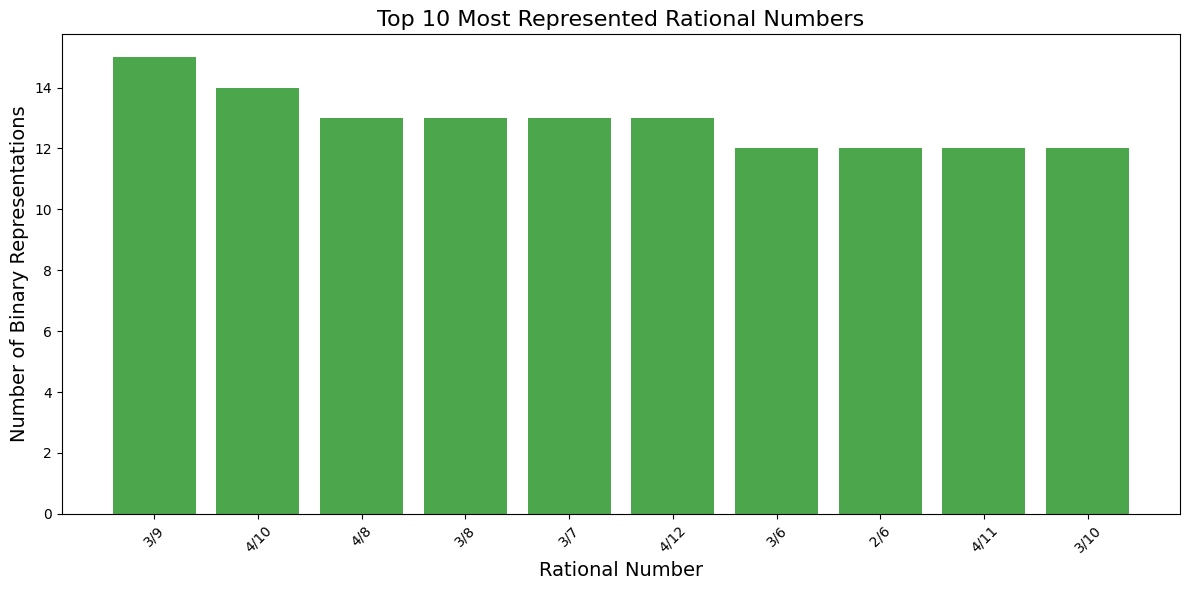

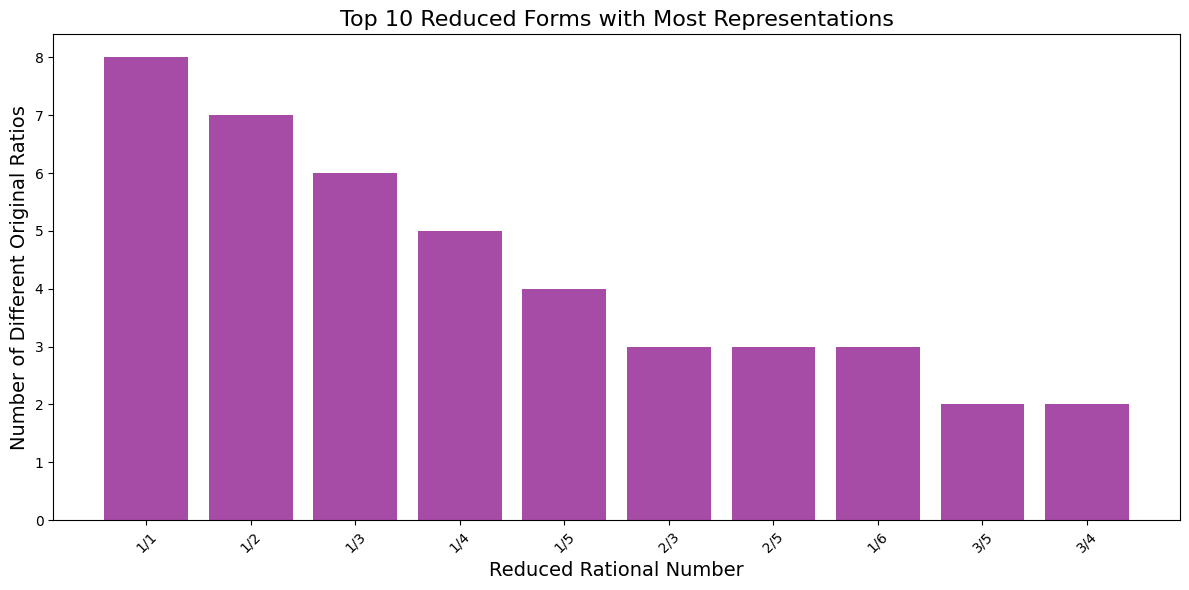


Rational: 1/2
Total representations: 7
Sample representations (up to 5):
  1. Binary: 11 (cardinality: 2)
     Decoded sets: [{1}, {1}]
  2. Binary: 110 (cardinality: 3)
     Decoded sets: [{1}, {1}]
  3. Binary: 1100 (cardinality: 4)
     Decoded sets: [{1}, {1}]
  4. Binary: 11000 (cardinality: 5)
     Decoded sets: [{1}, {1}]
  5. Binary: 110000 (cardinality: 6)
     Decoded sets: [{1}, {1}]

Rational: 2/3
Total representations: 6
Sample representations (up to 5):
  1. Binary: 101 (cardinality: 3)
     Decoded sets: [{1}, {1, 2}]
  2. Binary: 1010 (cardinality: 4)
     Decoded sets: [{1}, {1, 2}]
  3. Binary: 10100 (cardinality: 5)
     Decoded sets: [{1}, {1, 2}]
  4. Binary: 101000 (cardinality: 6)
     Decoded sets: [{1}, {1, 2}]
  5. Binary: 1010000 (cardinality: 7)
     Decoded sets: [{1}, {1, 2}]

Rational: 3/4
Total representations: 5
Sample representations (up to 5):
  1. Binary: 1001 (cardinality: 4)
     Decoded sets: [{1}, {1, 2, 3}]
  2. Binary: 10010 (cardinality: 5)
 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction
import numpy as np

def decode_binary_string(binary_str):
    decoded_sets = []
    positions_of_ones = [i for i, bit in enumerate(binary_str) if bit == '1']
    next_set_index = 0

    for position in positions_of_ones:
        n = next_set_index
        cardinality = position - n + 1
        if cardinality <= 0:
            raise ValueError(f"Invalid cardinality ({cardinality}) at position {position}.")
        current_set = set(range(1, cardinality + 1))
        decoded_sets.append(current_set)
        next_set_index += 1

    return decoded_sets

def set_union_ratio(collection_of_sets):
    if not collection_of_sets:
        return (0, 1)  # Return 0/1 for empty collections
    
    union_of_sets = set().union(*collection_of_sets)
    sum_of_cardinalities = sum(len(s) for s in collection_of_sets)
    
    if sum_of_cardinalities == 0:
        return (0, 1)
    return (len(union_of_sets), sum_of_cardinalities)

def generate_powerset_binary_strings(cardinality):
    return [''.join(bits) for bits in product('01', repeat=cardinality)]

def generate_dataframe(cardinality_range):
    results = []
    for set_cardinality in cardinality_range:
        binary_strings = generate_powerset_binary_strings(set_cardinality)
        for binary in binary_strings:
            try:
                decoded = decode_binary_string(binary)
                numerator, denominator = set_union_ratio(decoded)
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': decoded,
                    'Union Ratio Numerator': numerator,
                    'Union Ratio Denominator': denominator
                })
            except ValueError as e:
                results.append({
                    'Set Cardinality': set_cardinality,
                    'Binary String': binary,
                    'Decoded Sets': str(e),
                    'Union Ratio Numerator': None,
                    'Union Ratio Denominator': None
                })

    df = pd.DataFrame(results)
    return df

def build_rational_dictionary(max_cardinality):
    # Dictionary to store rational numbers and their binary representations
    # Key will be a tuple (numerator, denominator) to preserve the original ratio
    rational_dict = {}
    
    for cardinality in range(1, max_cardinality + 1):
        # Generate all binary strings of length 'cardinality'
        binary_strings = generate_powerset_binary_strings(cardinality)
        
        for binary in binary_strings:
            try:
                # Decode the binary string into sets
                decoded_sets = decode_binary_string(binary)
                
                # Calculate the ratio
                numerator, denominator = set_union_ratio(decoded_sets)
                
                # Create a tuple key instead of using Fraction (to avoid reduction)
                if denominator > 0:
                    # Use a tuple (numerator, denominator) as the key
                    ratio_key = (numerator, denominator)
                    
                    # Add to dictionary
                    if ratio_key not in rational_dict:
                        rational_dict[ratio_key] = []
                    
                    rational_dict[ratio_key].append({
                        "binary": binary, 
                        "cardinality": cardinality,
                        "decoded_sets": decoded_sets
                    })
                    
            except ValueError:
                # Skip invalid decodings
                continue
                
    return rational_dict

def analyze_rational_dictionary(rational_dict):
    # Count how many representations each rational has
    representation_counts = {ratio: len(representations) for ratio, representations in rational_dict.items()}
    
    # Find rationals with the most representations
    most_represented = sorted(representation_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    
    # Analyze which cardinalities introduce new rationals
    rationals_by_cardinality = {}
    for ratio, representations in rational_dict.items():
        min_cardinality = min(rep["cardinality"] for rep in representations)
        if min_cardinality not in rationals_by_cardinality:
            rationals_by_cardinality[min_cardinality] = []
        rationals_by_cardinality[min_cardinality].append(ratio)
    
    # Count new rationals introduced at each cardinality
    new_rationals_count = {card: len(ratios) for card, ratios in rationals_by_cardinality.items()}
    
    # Group rationals by their reduced form to see how many different representations have the same value
    from fractions import Fraction
    reduced_form_groups = {}
    for ratio_key in rational_dict.keys():
        numerator, denominator = ratio_key
        reduced_form = Fraction(numerator, denominator)
        if reduced_form not in reduced_form_groups:
            reduced_form_groups[reduced_form] = []
        reduced_form_groups[reduced_form].append(ratio_key)
    
    # Count how many original ratios reduce to the same value
    reduced_form_counts = {reduced: len(originals) for reduced, originals in reduced_form_groups.items()}
    most_reduced = sorted(reduced_form_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    
    return {
        "most_represented_rationals": most_represented,
        "new_rationals_by_cardinality": new_rationals_count,
        "rationals_by_cardinality": rationals_by_cardinality,
        "reduced_form_groups": reduced_form_groups,
        "most_reduced_forms": most_reduced
    }

def plot_cumulative_ratios(df, cardinality_range):
    plt.figure(figsize=(12, 8))
    seen_points = set()
    colors = ['gold', 'orange', 'red', 'purple', 'blue']

    for idx, cardinality in enumerate(cardinality_range):
        subset_df = df[
            (df['Set Cardinality'] == cardinality) &
            (df['Union Ratio Numerator'].notnull())
        ]

        current_points = set(zip(subset_df['Union Ratio Denominator'], subset_df['Union Ratio Numerator']))
        new_points = current_points - seen_points
        seen_points.update(new_points)

        if new_points:
            x, y = zip(*new_points)
            plt.scatter(
                x, y,
                s=80,
                alpha=0.7,
                edgecolors='k',
                color=colors[idx % len(colors)],
                label=f'Cardinality {cardinality}'
            )

    plt.title('Cumulative Unique Set Union Ratios by Cardinality', fontsize=16)
    plt.xlabel('Union Ratio Denominator (Sum of Cardinalities)', fontsize=14)
    plt.ylabel('Union Ratio Numerator (Size of Union)', fontsize=14)
    plt.legend(title='Set Cardinality', fontsize=12, title_fontsize=12)
    plt.grid(True)
    plt.show()

def plot_new_rationals_by_cardinality(analysis_results):
    cardinalities = list(analysis_results["new_rationals_by_cardinality"].keys())
    new_rationals = list(analysis_results["new_rationals_by_cardinality"].values())
    
    # Calculate cumulative rationals
    cumulative_rationals = np.cumsum(new_rationals)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot new rationals per cardinality
    ax1.bar(cardinalities, new_rationals, color='skyblue', alpha=0.7, label='New Rationals')
    ax1.set_xlabel('Cardinality', fontsize=14)
    ax1.set_ylabel('Number of New Rationals', fontsize=14, color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')
    
    # Second y-axis for cumulative count
    ax2 = ax1.twinx()
    ax2.plot(cardinalities, cumulative_rationals, color='red', linewidth=2, marker='o', label='Cumulative Rationals')
    ax2.set_ylabel('Cumulative Number of Rationals', fontsize=14, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Title and legend
    plt.title('New Rational Numbers Introduced by Cardinality', fontsize=16)
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

def display_most_represented_rationals(analysis_results):
    most_represented = analysis_results["most_represented_rationals"]
    
    plt.figure(figsize=(12, 6))
    ratios = [f"{num}/{den}" for (num, den), count in most_represented]
    counts = [count for _, count in most_represented]
    
    plt.bar(ratios, counts, color='green', alpha=0.7)
    plt.xlabel('Rational Number', fontsize=14)
    plt.ylabel('Number of Binary Representations', fontsize=14)
    plt.title('Top 10 Most Represented Rational Numbers', fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Also display the most common reduced forms
    if "most_reduced_forms" in analysis_results:
        plt.figure(figsize=(12, 6))
        most_reduced = analysis_results["most_reduced_forms"]
        reduced_ratios = [f"{ratio.numerator}/{ratio.denominator}" for ratio, count in most_reduced]
        reduced_counts = [count for _, count in most_reduced]
        
        plt.bar(reduced_ratios, reduced_counts, color='purple', alpha=0.7)
        plt.xlabel('Reduced Rational Number', fontsize=14)
        plt.ylabel('Number of Different Original Ratios', fontsize=14)
        plt.title('Top 10 Reduced Forms with Most Representations', fontsize=16)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

def display_rational_representation_examples(rational_dict, selected_ratios):
    """
    Display examples of binary representations for selected rationals.
    
    Args:
        rational_dict: Dictionary mapping ratio tuples (n,d) to their representations
        selected_ratios: List of tuples (numerator, denominator) to display
    """
    for num, den in selected_ratios:
        ratio_key = (num, den)
        if ratio_key in rational_dict:
            print(f"\nRational: {num}/{den}")
            print(f"Total representations: {len(rational_dict[ratio_key])}")
            print("Sample representations (up to 5):")
            
            # Display up to 5 examples sorted by cardinality
            examples = sorted(rational_dict[ratio_key], key=lambda x: x["cardinality"])[:5]
            for i, example in enumerate(examples, 1):
                print(f"  {i}. Binary: {example['binary']} (cardinality: {example['cardinality']})")
                print(f"     Decoded sets: {example['decoded_sets']}")
        else:
            print(f"\nRational {num}/{den} not found in dictionary.")

def main():
    # Set the maximum cardinality to explore
    max_cardinality = 8
    cardinality_range = range(1, max_cardinality + 1)
    
    # Generate the dataframe (original approach)
    df = generate_dataframe(cardinality_range)
    
    # Build the rational dictionary (new approach)
    rational_dict = build_rational_dictionary(max_cardinality)
    
    # Analyze the dictionary
    analysis_results = analyze_rational_dictionary(rational_dict)
    
    # Generate various visualizations
    plot_cumulative_ratios(df, cardinality_range)
    plot_new_rationals_by_cardinality(analysis_results)
    display_most_represented_rationals(analysis_results)
    
    # Display examples for specific rationals of interest (as tuples now)
    selected_ratios = [(1, 2), (2, 3), (3, 4), (2, 4), (4, 8)]
    display_rational_representation_examples(rational_dict, selected_ratios)
    
    # Print overall statistics
    total_rationals = len(rational_dict)
    print(f"\nTotal unique rational numbers found (without reduction): {total_rationals}")
    
    # Count unique reduced rationals
    from fractions import Fraction
    unique_reduced = {Fraction(num, den) for num, den in rational_dict.keys()}
    print(f"Total unique reduced rational numbers: {len(unique_reduced)}")
    
    # Optionally, you can save the dictionary to a file for further analysis
    # import json
    # with open('rational_dict_serializable.json', 'w') as f:
    #     # Convert to a serializable format first
    #     serializable_dict = {f"{num}/{den}": 
    #                         [{**v, "decoded_sets": str(v["decoded_sets"])} for v in vs] 
    #                         for (num, den), vs in rational_dict.items()}
    #     json.dump(serializable_dict, f)

if __name__ == "__main__":
    main()

In [10]:
pip install sentence-transformers


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\tomas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
print(model)


C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomas\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
